# 🏢 HR Employee Attrition Analysis
### End-to-End EDA | Python · Pandas · Matplotlib · Seaborn
**Dataset:** IBM HR Analytics Employee Attrition (Kaggle)  
**Author:** Dhruv Goel  
**Objective:** Identify why employees leave, who is most at risk, and recommend data-driven retention strategies.


🔃 First we import all the required libraries into our code 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load & Inspect the Dataset

In [2]:
df = pd.read_csv('IBM_HR_Dataset.csv')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


We will add a Serial Number column to verify the count and for ease of read

In [5]:
df.insert(0,'S.No.',range(1,len(df)+1))

#we can use simple assigment too to add the s.no. column
#df['S.No.'] = range(1,len(df)+1)

In [6]:
df.head()

,S.No.,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2


In [7]:
df.tail()

,S.No.,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,1466,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,...,3,80,1,17,3,3,5,2,0,3
1466,1467,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,...,1,80,1,9,5,3,7,7,1,7
1467,1468,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,...,2,80,1,6,0,3,6,2,0,3
1468,1469,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,...,4,80,0,17,3,2,9,6,0,8
1469,1470,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,...,1,80,0,6,3,4,4,3,1,2


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   S.No.                     1470 non-null   int64 
 1   Age                       1470 non-null   int64 
 2   Attrition                 1470 non-null   object
 3   BusinessTravel            1470 non-null   object
 4   DailyRate                 1470 non-null   int64 
 5   Department                1470 non-null   object
 6   DistanceFromHome          1470 non-null   int64 
 7   Education                 1470 non-null   int64 
 8   EducationField            1470 non-null   object
 9   EmployeeCount             1470 non-null   int64 
 10  EmployeeNumber            1470 non-null   int64 
 11  EnvironmentSatisfaction   1470 non-null   int64 
 12  Gender                    1470 non-null   object
 13  HourlyRate                1470 non-null   int64 
 14  JobInvolvement          

We use df.info() to see if any datatype of column is not what was intended and seeing above data we have verified that presence of such data isnt there

In [9]:
df.describe().T.style.background_gradient(cmap='Blues')


,count,mean,std,min,25%,50%,75%,max
S.No.,1470.000000,735.500000,424.496761,1.000000,368.250000,735.500000,1102.750000,1470.000000
Age,1470.000000,36.923810,9.135373,18.000000,30.000000,36.000000,43.000000,60.000000
DailyRate,1470.000000,802.485714,403.509100,102.000000,465.000000,802.000000,1157.000000,1499.000000
DistanceFromHome,1470.000000,9.192517,8.106864,1.000000,2.000000,7.000000,14.000000,29.000000
Education,1470.000000,2.912925,1.024165,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeCount,1470.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1470.000000,1024.865306,602.024335,1.000000,491.250000,1020.500000,1555.750000,2068.000000
EnvironmentSatisfaction,1470.000000,2.721769,1.093082,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1470.000000,65.891156,20.329428,30.000000,48.000000,66.000000,83.750000,100.000000
JobInvolvement,1470.000000,2.729932,0.711561,1.000000,2.000000,3.000000,3.000000,4.000000


## Step 2: Data Cleaning

In [10]:
#First, Check missing values
missing = df.isnull().sum()
print("Missing values per column:",missing)

Missing values per column: S.No.                       0
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompan

In [11]:
#Check missing values in whole table
missing_total=missing.sum()
print('Total missing values in table',missing_total)

Total missing values in table 0


In [12]:
#Check for duplicate values in the table
dupes=df.duplicated().sum()
print('Duplicates in the table',dupes)

Duplicates in the table 0


In [13]:
#Encode Attrition as binary for correlation analysis later in a new column called Attrition_flag
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1,'No': 0})

In [14]:
print("New Attition flag column",df['Attrition_Flag'])

New Attition flag column 0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition_Flag, Length: 1470, dtype: int64


In [15]:
df.head()

,S.No.,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag
0,1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,80,0,8,0,1,6,4,0,5,1
1,2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,80,1,10,3,3,10,7,1,7,0
2,3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,80,0,7,3,3,0,0,0,0,1
3,4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,80,0,8,3,3,8,7,3,0,0
4,5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,80,1,6,3,3,2,2,2,2,0


In [16]:
#We should drop the unnecessary columns which have same values for every employee.
#Upon analysis we have identified three columns as Over18, StandardWorkingHours, EmployeeCount
df.drop(columns = ['EmployeeCount','Over18','StandardHours'])

,S.No.,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag
0,1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,1,0,8,0,1,6,4,0,5,1
1,2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,...,4,1,10,3,3,10,7,1,7,0
2,3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,...,2,0,7,3,3,0,0,0,0,1
3,4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,...,3,0,8,3,3,8,7,3,0,0
4,5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,...,4,1,6,3,3,2,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1466,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,...,3,1,17,3,3,5,2,0,3,0
1466,1467,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,...,1,1,9,5,3,7,7,1,7,0
1467,1468,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,...,2,1,6,0,3,6,2,0,3,0
1468,1469,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,...,4,0,17,3,2,9,6,0,8,0


## Step 3: Attrition Overview

In [17]:
#Total count for attrition
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [18]:
#Percentage for attrition
attrition_pct = round((df['Attrition'].value_counts(normalize = True)*100),2)
print(attrition_pct)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


#### Data for Attrition

In [19]:
Total_emp = len(df)
print("Total Employee Count:",Total_emp)

attr_cnt = attrition_counts['Yes']
print("Count of Employees who left the company:",attr_cnt)

attr_pct = attrition_pct['Yes']
print("Percentage of Employees who left:",attr_pct,"%")


attr_cnt_2 = attrition_counts['No']
print("Count of retained employees:",attr_cnt_2)

attr_pct_2 = attrition_pct['No']
print("Percentage of Retained Employees:",attr_pct_2,"%")

Total Employee Count: 1470
Count of Employees who left the company: 237
Percentage of Employees who left: 16.12 %
Count of retained employees: 1233
Percentage of Retained Employees: 83.88 %


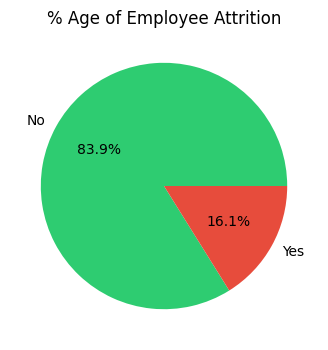

In [20]:
#Pie plot to see the percentage of attribition
plt.figure(figsize=(4,4))
plt.pie(attrition_pct,labels=['No','Yes'],autopct='%1.1f%%',colors=['#2ECC71', '#E74C3C'])
plt.title("% Age of Employee Attrition")
plt.show()

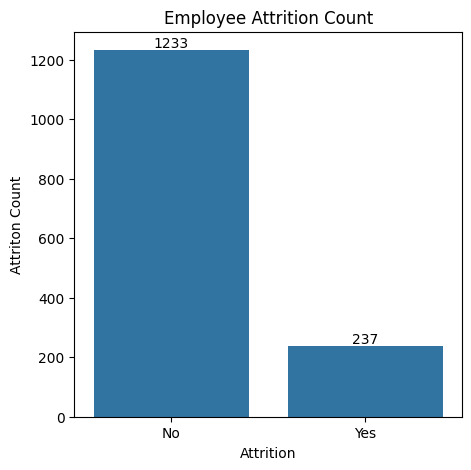

In [21]:
#Bar plot to see the count of Attribition
plt.figure(figsize=(5,5))
ax = sns.barplot(x=attrition_counts.index , y=attrition_counts.values)
for con in ax.containers:
   ax.bar_label(con)
plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Attriton Count")
plt.show()

From above data we can see attribition is around ~16% which means 1 in 6 employees are leaving. Industry standard is around ~10-12% which means this is above industry average and will need further analysis to determine why this has been happening.

## Step 4: Attrition by Department & Job Role

In [22]:
#Attrition by Department count using groupby and mean
dept_attr = (
    df.groupby('Department')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='AttritionRate')
)

dept_attr = dept_attr.sort_values(
    by='AttritionRate',
    ascending=False
)

print(dept_attr)

               Department  AttritionRate
2                   Sales      20.627803
0         Human Resources      19.047619
1  Research & Development      13.839750


C:\Users\Dhruv_5694\AppData\Local\Temp\ipykernel_18004\728880912.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


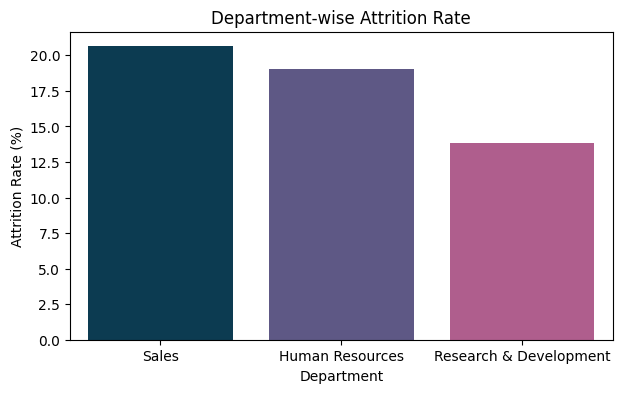

In [23]:
#Barplot to see department wise attrition rate between different departments.
plt.figure(figsize=(7,4))
retro_tech = ["#003f5c", "#58508d", "#bc5090"]
ax = sns.barplot(
    data=dept_attr,
    x='Department',
    y='AttritionRate',
    palette = retro_tech
)
plt.title('Department-wise Attrition Rate')
plt.ylabel('Attrition Rate (%)')
plt.show()

In [24]:
#Count of Employees left by department
dept_left = (
    df[df['Attrition'] == 'Yes']
      .groupby('Department')
      .size()
      .reset_index(name='EmployeesLeft')
)
print(dept_left)

               Department  EmployeesLeft
0         Human Resources             12
1  Research & Development            133
2                   Sales             92


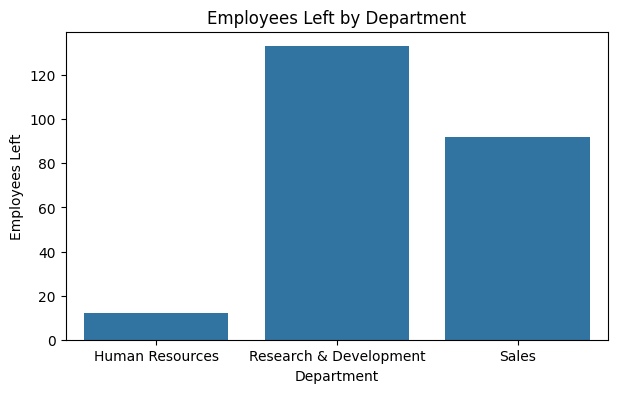

In [25]:
#Barplot to see department wise employee left count
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=dept_left,
    x='Department',
    y='EmployeesLeft'
)
plt.title('Employees Left by Department')
plt.ylabel('Employees Left')
plt.show()

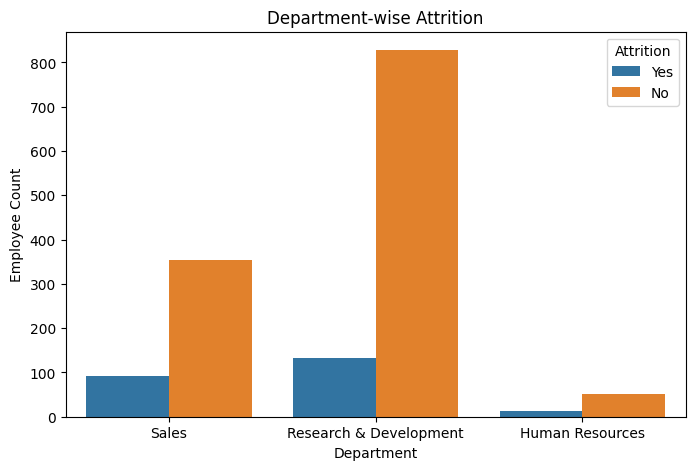

In [26]:
#Barplot to see department wise attrition 
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='Department',
    hue='Attrition'
)
plt.title('Department-wise Attrition')
plt.ylabel('Employee Count')
plt.show()

Analyzing above data of attrition on basis of department we can conclude that sales department has highest rate of attrition among departments followed closely by R&D but their employee count is way more so Sales department attrition is more alarming for the HR

In [27]:
#Rate of attrition by job role
jobrole_attr = df.groupby('JobRole').agg(
  Total_Emp = ('Attrition', 'count'),
    Emp_left = ('Attrition' , lambda x : (x=='Yes').sum()
))
jobrole_attr['att_rate_role'] = (jobrole_attr['Emp_left']/jobrole_attr['Total_Emp'])*100
jobrole_attr = jobrole_attr.sort_values(
    by='att_rate_role',
    ascending=False
)
print(jobrole_attr)

                           Total_Emp  Emp_left  att_rate_role
JobRole                                                      
Sales Representative              83        33      39.759036
Laboratory Technician            259        62      23.938224
Human Resources                   52        12      23.076923
Sales Executive                  326        57      17.484663
Research Scientist               292        47      16.095890
Manufacturing Director           145        10       6.896552
Healthcare Representative        131         9       6.870229
Manager                          102         5       4.901961
Research Director                 80         2       2.500000


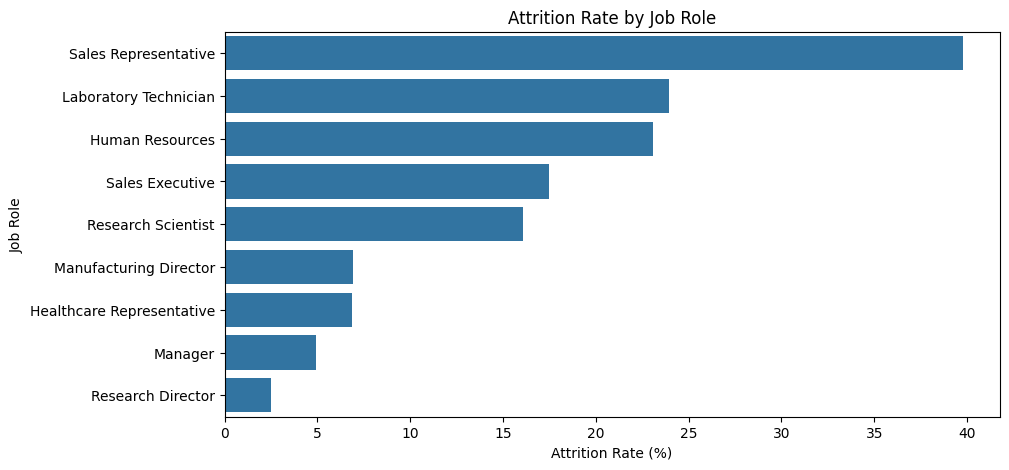

In [28]:
#Barplot to visualize attrition rate per job role
plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=jobrole_attr,
    x='att_rate_role',
    y='JobRole'
)
plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.show()

In [29]:
#Count of employees who left on basis of job role
role_left = (
    df[df['Attrition'] == 'Yes']
      .groupby('JobRole')
      .size()
      .reset_index(name='EmployeesLeft')
      .sort_values('EmployeesLeft', ascending=False)
)

print(role_left)

                     JobRole  EmployeesLeft
2      Laboratory Technician             62
7            Sales Executive             57
6         Research Scientist             47
8       Sales Representative             33
1            Human Resources             12
4     Manufacturing Director             10
0  Healthcare Representative              9
3                    Manager              5
5          Research Director              2


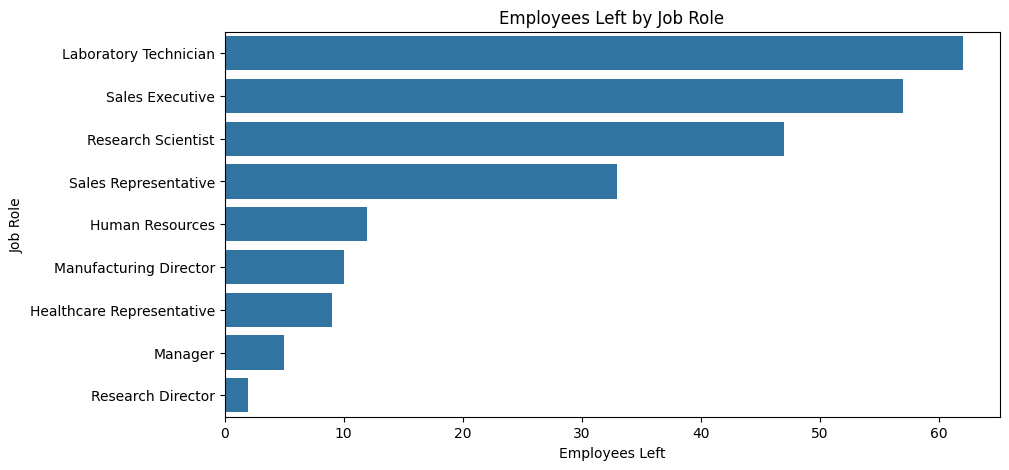

In [30]:
#Barplot to visualise the count of employees left by job role
plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=role_left,
    x='EmployeesLeft',
    y='JobRole'
)
plt.title('Employees Left by Job Role')
plt.xlabel('Employees Left')
plt.ylabel('Job Role')
plt.show()

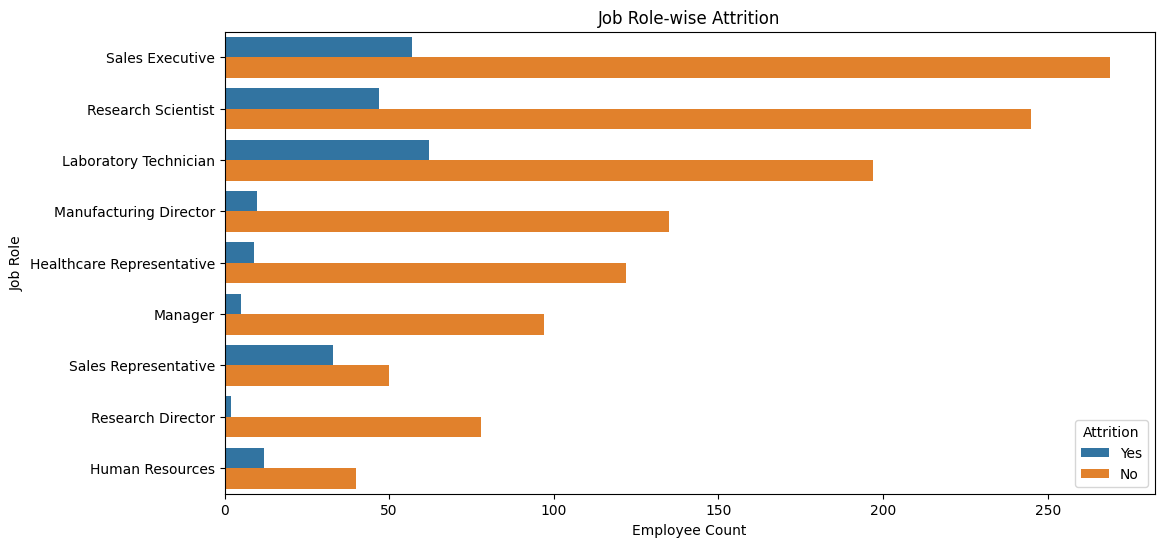

In [31]:
#Barplot to visualise the attrition count by job role
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y='JobRole',
    hue='Attrition'
)
plt.title('Job Role-wise Attrition')
plt.xlabel('Employee Count')
plt.ylabel('Job Role')
plt.show()

Analyzing above data of attrition on basis of job role we can conclude that sales rep role has one of highest rate of attrition among departments which follows our previous observation of department and verifies it too.
Along with sales rep Lab Tech job role also has high count of attrition which matches the previous finding of R&D high rate of attrition as well.

## 💰 Step 5: Salary & Compensation Analysis

In [32]:
#Average income per attrition type
avg_income = (
    df.groupby('Attrition')['MonthlyIncome']
      .mean()
      .reset_index(name='AvgIncome')
)

print(avg_income)

  Attrition    AvgIncome
0        No  6832.739659
1       Yes  4787.092827


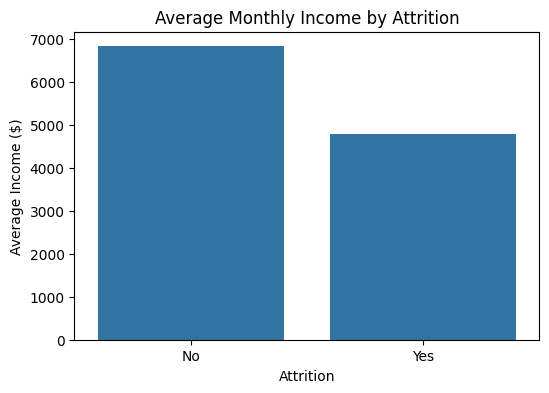

In [33]:
#Bar plot to visualise the average monthly income by attrition
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=avg_income,
    x='Attrition',
    y='AvgIncome'
)
plt.title('Average Monthly Income by Attrition')
plt.ylabel('Average Income ($)')
plt.show()

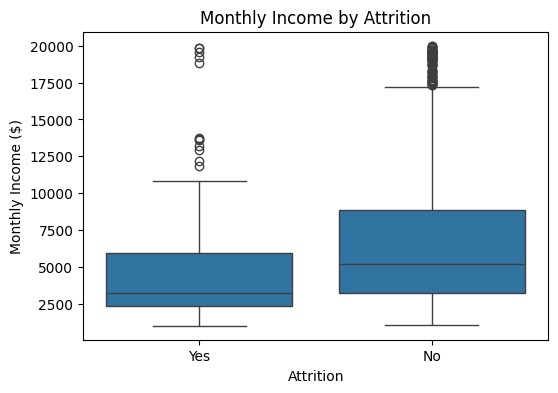

In [34]:
#Box graph to visualise monthly income of employees by attrition
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome'
)
plt.title('Monthly Income by Attrition')
plt.ylabel('Monthly Income ($)')
plt.show()

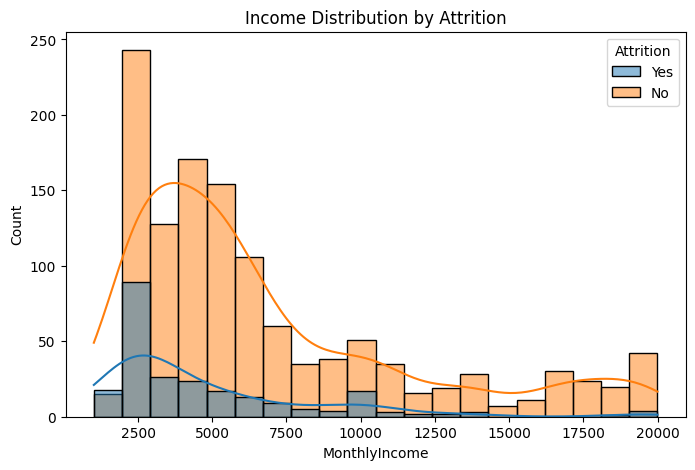

In [35]:
#Histogram to visualise the income distribution on basis of monthly income buckets and by attrition
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='MonthlyIncome',
    hue='Attrition',
    kde=True
)
plt.title('Income Distribution by Attrition')
plt.show()

In [36]:
#Comparison of Average income of employees who left and stayed 
left_avg = (
    df[df['Attrition'] == 'Yes']
    ['MonthlyIncome']
    .mean()
)
stayed_avg = (
    df[df['Attrition'] == 'No']
    ['MonthlyIncome']
    .mean()
)
print(f"Average Income (Left)   : ",left_avg)
print(f"Average Income (Stayed) : ",stayed_avg)
print(
    f"\nDifference : ${stayed_avg-left_avg:}"
)

Average Income (Left)   :  4787.0928270042195
Average Income (Stayed) :  6832.739659367397

Difference : $2045.646832363177


Analysing above data we can concude that people who have attritioned were paid less by average of around $2000 than those who stayed.

## ⚖️ Step 6: Work-Life Balance, Overtime & Job Satisfaction

In [37]:
#Rate of attrition by overtime
overtime_attr = (
    df.groupby('OverTime')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='AttritionRate')
)

print(overtime_attr)

  OverTime  AttritionRate
0       No      10.436433
1      Yes      30.528846


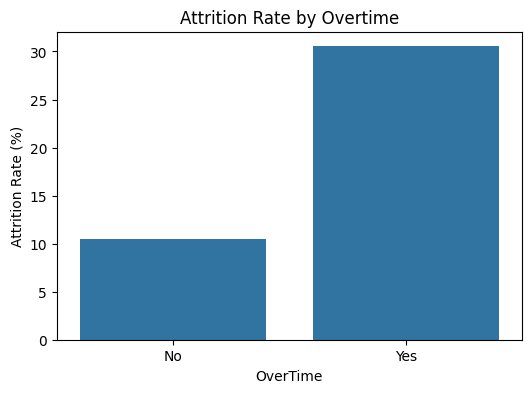

In [38]:
#Barplot to visualise the rate of attrition by overtime
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=overtime_attr,
    x='OverTime',
    y='AttritionRate'
)
plt.title('Attrition Rate by Overtime')
plt.ylabel('Attrition Rate (%)')
plt.show()

In [39]:
#Rate of attrition by worklife balance. We gave names to the rating provided in data for easier visualisation.
wlb_attr = (
    df.groupby('WorkLifeBalance')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='AttritionRate')
)
wlb_attr['WorkLifeBalance'] = wlb_attr['WorkLifeBalance'].map({   1:'Bad',
    2:'Good',
    3:'Better',
    4:'Best'})
print(wlb_attr)

  WorkLifeBalance  AttritionRate
0             Bad      31.250000
1            Good      16.860465
2          Better      14.221725
3            Best      17.647059


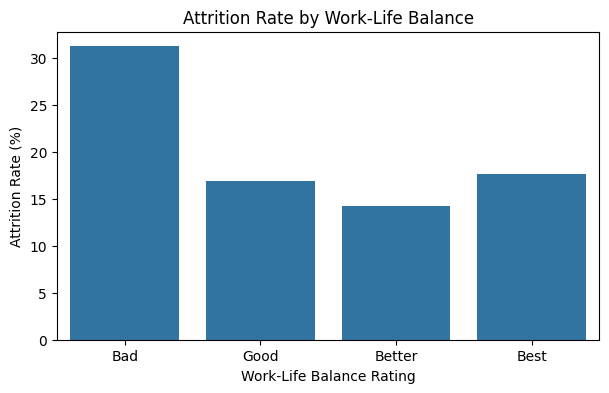

In [40]:
#Barplot to visualise the rate of attrition by work-life balance
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=wlb_attr,
    x='WorkLifeBalance',
    y='AttritionRate'
)
plt.title('Attrition Rate by Work-Life Balance')
plt.xlabel('Work-Life Balance Rating')
plt.ylabel('Attrition Rate (%)')
plt.show()

In [41]:
#Rate of attrition by job satisfaction. We gave names to the rating provided in data for easier visualisation.
job_sat_attr = (
    df.groupby('JobSatisfaction')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='AttritionRate')
)
job_sat_attr['JobSatisfaction'] = job_sat_attr['JobSatisfaction'].map({1:'Low', 2:'Medium', 3:'High', 4:'Very High'})

print(job_sat_attr)

  JobSatisfaction  AttritionRate
0             Low      22.837370
1          Medium      16.428571
2            High      16.515837
3       Very High      11.328976


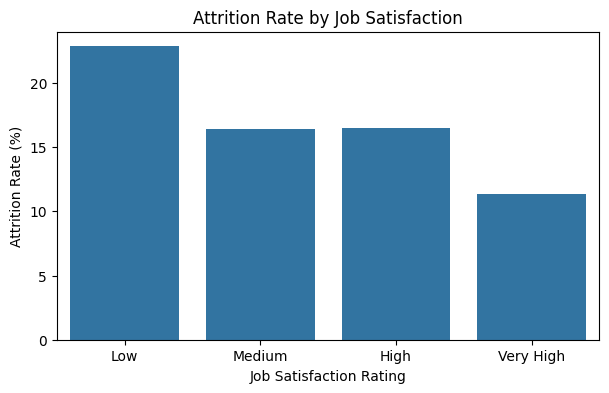

In [42]:
#Bar plot graph to compare attrition rate by job satisfaction ratings
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=job_sat_attr,
    x='JobSatisfaction',
    y='AttritionRate'
)
plt.title('Attrition Rate by Job Satisfaction')

plt.xlabel('Job Satisfaction Rating')

plt.ylabel('Attrition Rate (%)')

plt.show()

By studying above data of work-life balance, overtime and job satisfaction ratings, we can conclude several point:
1. Employees who work overtime are 20% more likely to attrition than employees who arent working overtime.
2. Employees with bad work life balance are twice more likely to attrition compared to the employees under other categories.
3. Employees with low job satisfaction rating are more likely to attrition compared to the employees under other categories by about 6%.

## 👤 Step 7: Age, Tenure & Experience Analysis

In [43]:
#We create a new column of Agebucket to analyse the data on basis of age
df['AgeBucket'] = pd.cut(
    df['Age'],
    bins=[18, 25, 30, 35, 45, 60],
    labels=['18-25', '26-30', '31-35', '36-45', '46-60']
)

In [44]:
#Rate of attrition on basis of age brackets
age_attr = (
    df.groupby('AgeBucket', observed=True)['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='AttritionRate')
)

print(age_attr)

  AgeBucket  AttritionRate
0     18-25      34.782609
1     26-30      21.292776
2     31-35      17.492711
3     36-45       9.188034
4     46-60      12.454212


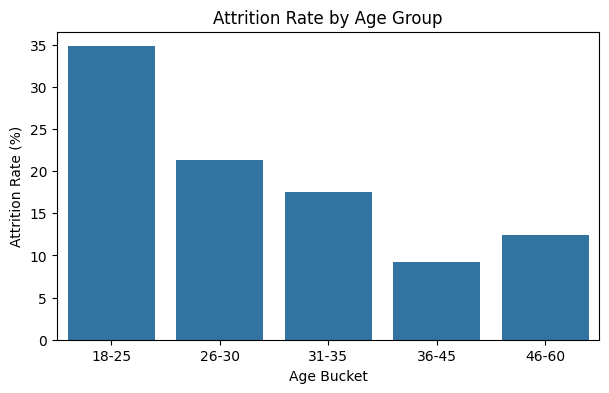

In [45]:
#Bar plot to visualise the attrition rate in comparison to the agebucket
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=age_attr,
    x='AgeBucket',
    y='AttritionRate'
)
plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Bucket')
plt.ylabel('Attrition Rate (%)')
plt.show()

In [46]:
#Average age of employees who have attritioned and employees who have not.
avg_age = (
    df.groupby('Attrition')['Age']
      .mean()
      .reset_index(name='AverageAge')
)
print(avg_age)

  Attrition  AverageAge
0        No   37.561233
1       Yes   33.607595


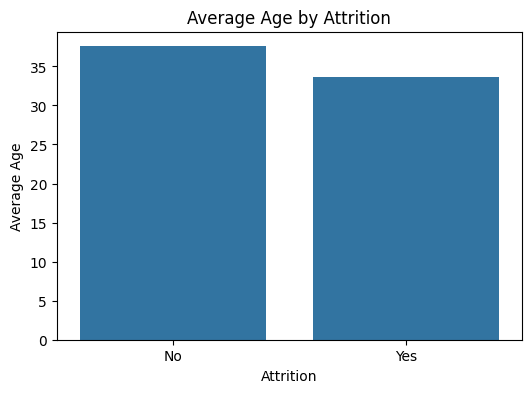

In [47]:
#Bar plot to visualise the difference between average age of employees who have attritioned and who have not.
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=avg_age,
    x='Attrition',
    y='AverageAge'
)
plt.title('Average Age by Attrition')
plt.ylabel('Average Age')
plt.show()

In [48]:
#Attrition rate of employees on basis of the years they have served at the company.
#We intentionally sort it and then print it to show top 10 data figures for precise data.
tenure_attr = (
    df.groupby('YearsAtCompany')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='AttritionRate')
)
tenure_attr = tenure_attr.sort_values(by='AttritionRate',ascending=False)
print(tenure_attr.head(10))

    YearsAtCompany  AttritionRate
36              40     100.000000
23              23      50.000000
0                0      36.363636
1                1      34.502924
31              32      33.333333
30              31      33.333333
2                2      21.259843
32              33      20.000000
4                4      17.272727
24              24      16.666667


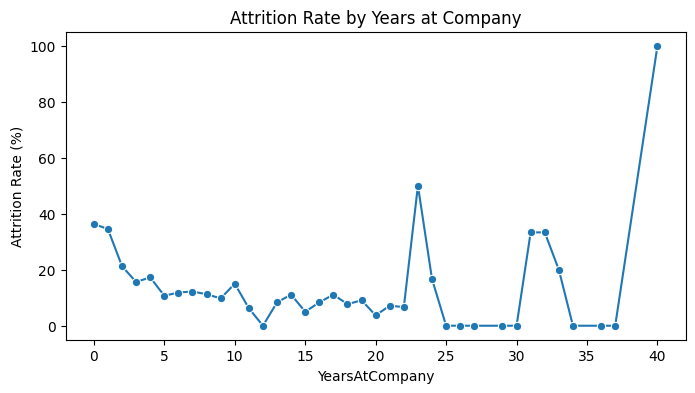

In [49]:
#Line plot to visualise attrition rate by years at company. We use line plot to clearly see how the trend has been going for detailed info.
plt.figure(figsize=(8,4))
sns.lineplot(
    data=tenure_attr,
    x='YearsAtCompany',
    y='AttritionRate',
    marker='o'
)
plt.title('Attrition Rate by Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.show()

In [50]:
#Rate of attrition on basis of how many years it has been since they last got promoted.
#We intentionally sort it in descending order and use head(10) to see top 10 data
promotion_attr = (
    df.groupby('YearsSinceLastPromotion')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='AttritionRate')
)
promotion_attr = promotion_attr.sort_values(by='AttritionRate',ascending=False)
print(promotion_attr.head(10))

    YearsSinceLastPromotion  AttritionRate
9                         9      23.529412
15                       15      23.076923
7                         7      21.052632
13                       13      20.000000
0                         0      18.932874
6                         6      18.750000
3                         3      17.307692
2                         2      16.981132
10                       10      16.666667
1                         1      13.725490


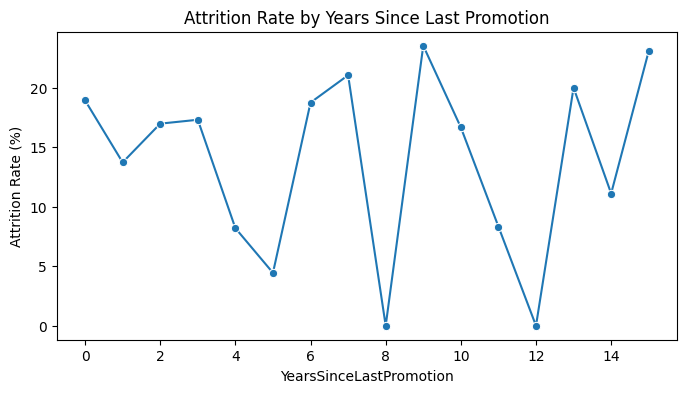

In [51]:
#Line plot to visualise the attrition rate by last promotion year to see the trend that has been shaping to see if there are any patterns involved.
plt.figure(figsize=(8,4))
sns.lineplot(
    data=promotion_attr,
    x='YearsSinceLastPromotion',
    y='AttritionRate',
    marker='o'
)
plt.title('Attrition Rate by Years Since Last Promotion')
plt.ylabel('Attrition Rate (%)')
plt.show()

Above data has given us different conclusions which may help in finding the cause of attrition:

1. In case of age, it has been observed that attrition rate for younger employees between the age of 18-25 is way more than other age ranges which means thay younger employees are leaving the company in search of growth or better paying oppurtunities which is something to look into.

2. Average age of employees for attrition showed the same that younger employees are more likely to attrition than the older employees.

3. Data for attrition rate by years the employee has served in company has showed some results that along verification of higher rate of attrition among young employees, employees who have served company for more than 30 years have high attrition rate too which may mean that highly experienced individuals are maybe being poached by other companies with better pay or options that our company is failing to provide.

4. Data for attrition rate among employees on basis on when they were last promoted has followed suit as well to show that people who have not been promoted for more than 6 years are leaving the company as their rate of attrition are among the highest.

## 💡 Step 9: Business Insights & Recommendations

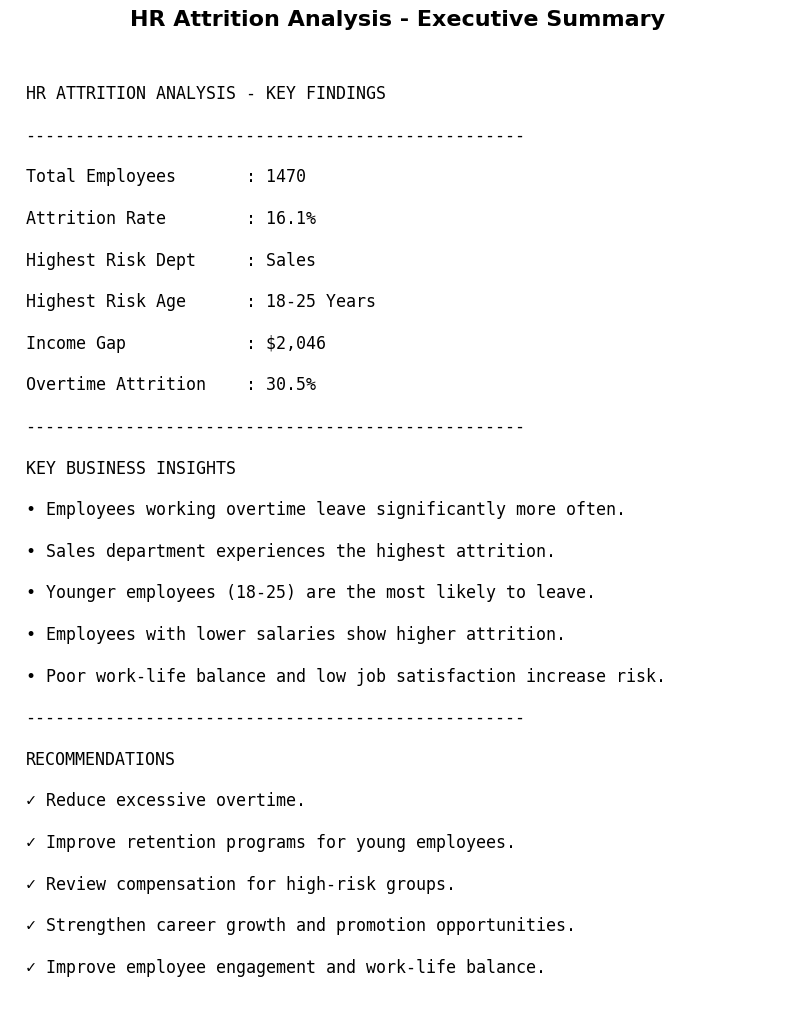

In [52]:
plt.figure(figsize=(10,6))
plt.axis('off')

summary = f"""

HR ATTRITION ANALYSIS - KEY FINDINGS

--------------------------------------------------

Total Employees       : {len(df)}

Attrition Rate        : {df['Attrition_Flag'].mean()*100:.1f}%

Highest Risk Dept     : Sales

Highest Risk Age      : 18-25 Years

Income Gap            : ${df[df['Attrition']=='No']['MonthlyIncome'].mean() - df[df['Attrition']=='Yes']['MonthlyIncome'].mean():,.0f}

Overtime Attrition    : {df[df['OverTime']=='Yes']['Attrition_Flag'].mean()*100:.1f}%

--------------------------------------------------

KEY BUSINESS INSIGHTS

• Employees working overtime leave significantly more often.

• Sales department experiences the highest attrition.

• Younger employees (18-25) are the most likely to leave.

• Employees with lower salaries show higher attrition.

• Poor work-life balance and low job satisfaction increase risk.

--------------------------------------------------

RECOMMENDATIONS

✓ Reduce excessive overtime.

✓ Improve retention programs for young employees.

✓ Review compensation for high-risk groups.

✓ Strengthen career growth and promotion opportunities.

✓ Improve employee engagement and work-life balance.

"""

plt.text(
    0.02,
    0.98,
    summary,
    fontsize=12,
    va='top',
    family='monospace'
)

plt.title(
    "HR Attrition Analysis - Executive Summary",
    fontsize=16,
    fontweight='bold'
)

plt.show()

In [53]:
df.head()

,S.No.,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag,AgeBucket
0,1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,0,8,0,1,6,4,0,5,1,36-45
1,2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,1,10,3,3,10,7,1,7,0,46-60
2,3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,0,7,3,3,0,0,0,0,1,36-45
3,4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,0,8,3,3,8,7,3,0,0,31-35
4,5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,1,6,3,3,2,2,2,2,0,26-30


## 📤 Step 10: Export Cleaned Data for Power BI

In [54]:
# Create a copy for Power BI
powerbi_df = df.copy()

# Convert numeric ratings into labels using map so it can be used in powerbi more efficiently without any confusion
powerbi_df['WorkLifeBalance'] = powerbi_df['WorkLifeBalance'].map({
    1:'Bad',
    2:'Good',
    3:'Better',
    4:'Best'
})

powerbi_df['JobSatisfaction'] = powerbi_df['JobSatisfaction'].map({
    1:'Low',
    2:'Medium',
    3:'High',
    4:'Very High'
})

powerbi_df['EnvironmentSatisfaction'] = powerbi_df['EnvironmentSatisfaction'].map({
    1:'Low',
    2:'Medium',
    3:'High',
    4:'Very High'
})

# Create Tenure Group
powerbi_df['TenureGroup'] = pd.cut(
    powerbi_df['YearsAtCompany'],
    bins=[0,1,3,7,15,40],
    labels=['<1 Year','1-3 Years','3-7 Years','7-15 Years','15+ Years']
)

# Create Income Group
powerbi_df['IncomeGroup'] = pd.cut(
    powerbi_df['MonthlyIncome'],
    bins=[0,3000,6000,10000,20000],
    labels=['Low','Medium','High','Very High']
)

# Export File for powerbi manupulation
powerbi_df.to_csv(
    'HR_Attrition_PowerBI.csv',
    index=False
)

print("File exported successfully")
print(f"Rows: {powerbi_df.shape[0]}")
print(f"Columns: {powerbi_df.shape[1]}")

File exported successfully
Rows: 1470
Columns: 40
